# Exploratory Data Analysis: Retail Sales Dataset

**Objective:** uncover sales patterns, customer behavior trends, product/category performance, and actionable business recommendations.

**Dataset used:** `retail_sales_dataset.csv` copied alongside this notebook for reproducibility.

**Coverage:** 1,000 transactions, 12 original columns, from 2023-01-01 to 2024-01-01.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

DATA_PATH = Path("retail_sales_dataset.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 1. Load Dataset and Initial Inspection

This section checks the size of the dataset, column types, duplicates, date coverage, and missing values before analysis.

In [4]:
print("Shape:", df.shape)
display(df.info())
display(df.head())
display(df.tail())
display(df.isna().sum().to_frame("Missing Values"))
print("Duplicate rows:", df.duplicated().sum())

Shape: (1000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


None

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


,Missing Values
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


Duplicate rows: 0


**Observation:** The dataset contains 1,000 rows and 12 columns. There are 0 missing values, so no imputation is needed before the EDA. The `Date` column starts as text and should be converted to datetime for time-series analysis.

In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

age_bins = [0, 24, 34, 44, 54, 64, 120]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df["Age Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

print("Date range:", df["Date"].min(), "to", df["Date"].max())
display(df.head())

Date range: 2023-01-01 00:00:00 to 2024-01-01 00:00:00


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11-01,2023Q4,25-34
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02-01,2023Q1,25-34
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01-01,2023Q1,45-54
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05-01,2023Q2,35-44
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05-01,2023Q2,25-34


## 2. Descriptive Statistics

The checklist asks for mean, median, mode, and standard deviation for every numerical column.

In [6]:
numeric_cols = df.select_dtypes(include="number").columns

descriptive_stats = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "mode": df[numeric_cols].mode().iloc[0],
    "std_dev": df[numeric_cols].std()
}).round(2)

display(descriptive_stats)

,mean,median,mode,std_dev
Transaction ID,500.50,500.5,1.0,288.82
Age,41.39,42.0,43.0,13.68
Quantity,2.51,3.0,4.0,1.13
Price per Unit,179.89,50.0,50.0,189.68
Total Amount,456.00,135.0,50.0,560.00


**Observation:** Total revenue across all transactions is **$456,000**, and the average order value is **$456.00**. `Transaction ID` is numeric but acts as an identifier, so the most useful numerical behavior comes from age, quantity, price per unit, and total amount.

## 3. Time Series Analysis

Monthly and quarterly line charts reveal seasonal or period-based changes in sales.

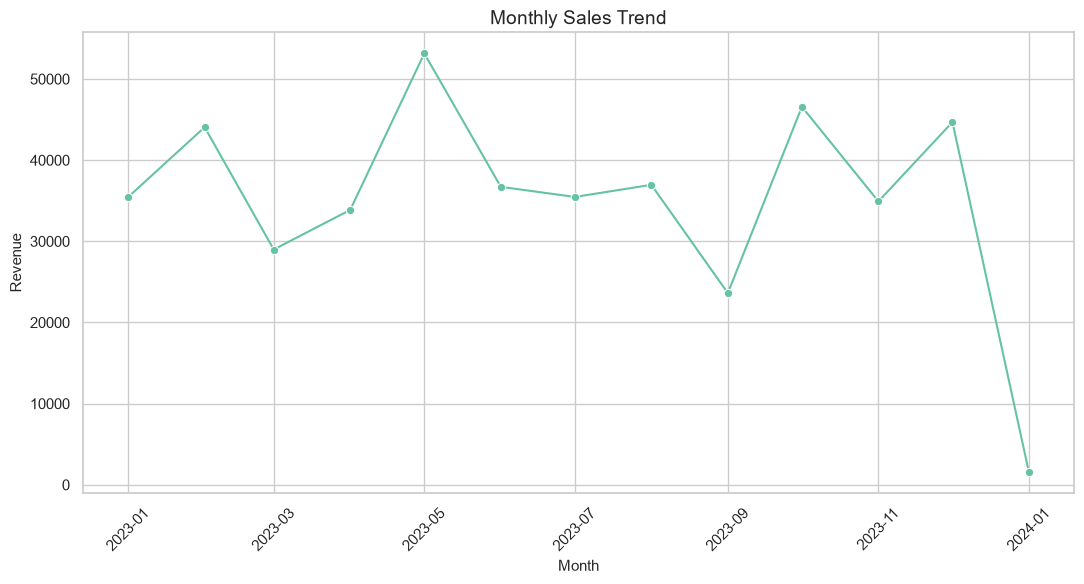

In [7]:
monthly_sales = df.groupby("Month", as_index=False)["Total Amount"].sum()

ax = sns.lineplot(data=monthly_sales, x="Month", y="Total Amount", marker="o")
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** The strongest month is **May 2023** with **$53,150** in sales. Monthly revenue is not flat; this points to meaningful seasonality or campaign timing that should be compared with promotions, holidays, and inventory availability.

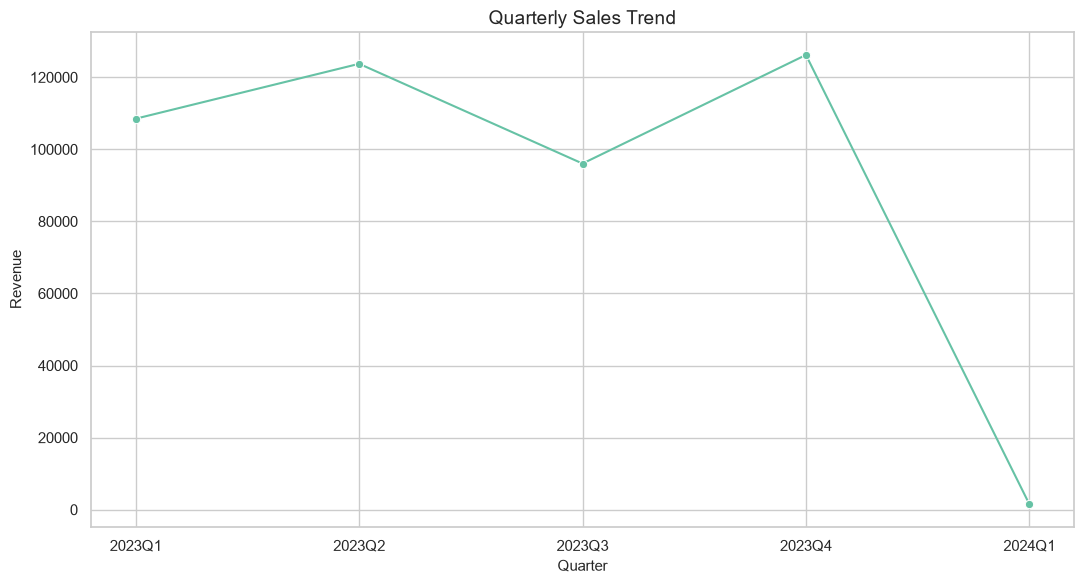

In [8]:
quarterly_sales = df.groupby("Quarter", as_index=False)["Total Amount"].sum()

ax = sns.lineplot(data=quarterly_sales, x="Quarter", y="Total Amount", marker="o")
ax.set_title("Quarterly Sales Trend")
ax.set_xlabel("Quarter")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

**Observation:** Among complete 2023 quarters, **2023Q4** is the strongest with **$126,190**. The single 2024-01-01 record creates a tiny 2024Q1 value, so it should not be interpreted as a full-quarter decline.

## 4. Customer Demographics Analysis

This section examines age groups and gender breakdown to understand who is buying.

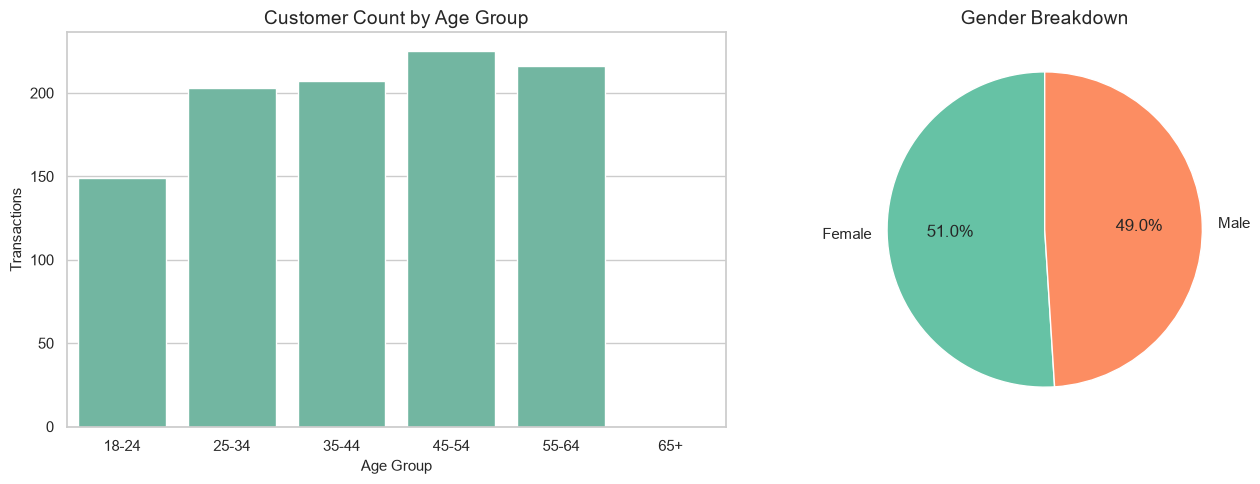

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Age Group", order=age_labels, ax=axes[0])
axes[0].set_title("Customer Count by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Transactions")

gender_counts = df["Gender"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Gender Breakdown")

plt.tight_layout()
plt.show()

**Observation:** The largest age band is **45-54** with **225** transactions. Gender participation is balanced: **Female** customers contribute the slightly higher revenue total at **$232,840**, but the gap is small.

,Gender,transactions,revenue,avg_order_value
0,Female,510,232840,456.549020
1,Male,490,223160,455.428571


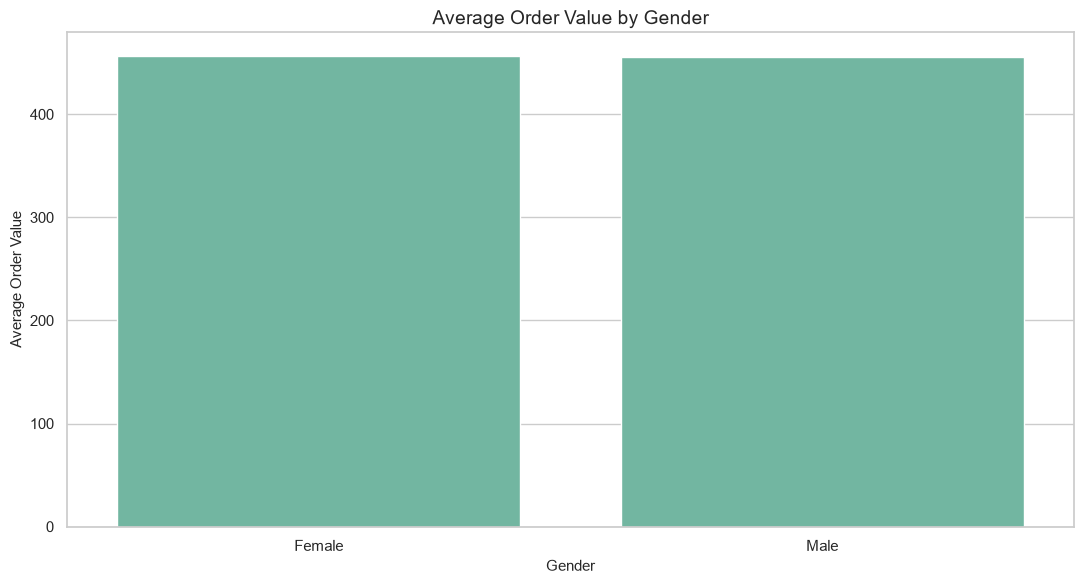

In [10]:
gender_revenue = df.groupby("Gender", as_index=False).agg(
    transactions=("Transaction ID", "count"),
    revenue=("Total Amount", "sum"),
    avg_order_value=("Total Amount", "mean")
)
display(gender_revenue)

ax = sns.barplot(data=gender_revenue, x="Gender", y="avg_order_value")
ax.set_title("Average Order Value by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Average Order Value")
plt.tight_layout()
plt.show()

**Observation:** Average order value is nearly identical between male and female customers, so broad gender-based pricing or discount strategy is unlikely to be the highest-return segmentation lever in this dataset.

## 5. Product Analysis

The dataset includes `Product Category` but not individual product names or SKUs. Therefore, the best-selling product analysis is performed at the available category level.

,transactions,units_sold,revenue,avg_order_value
Product Category,,,,
Clothing,351,894,155580,443.247863
Electronics,342,849,156905,458.786550
Beauty,307,771,143515,467.475570


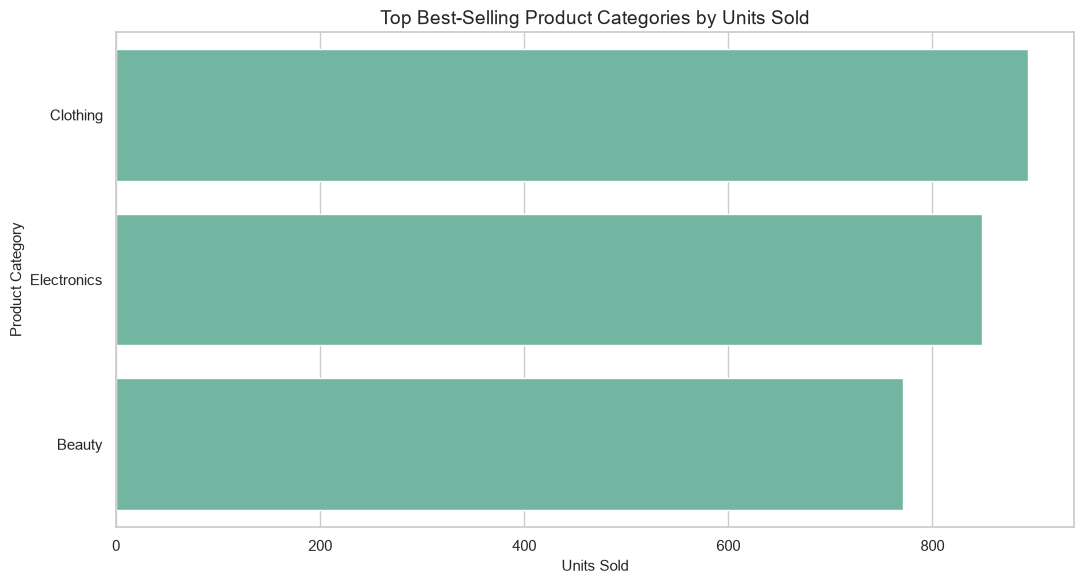

In [11]:
category_summary = (
    df.groupby("Product Category")
    .agg(
        transactions=("Transaction ID", "count"),
        units_sold=("Quantity", "sum"),
        revenue=("Total Amount", "sum"),
        avg_order_value=("Total Amount", "mean")
    )
    .sort_values("units_sold", ascending=False)
)

display(category_summary)

top_10_products_available = category_summary.head(10)
ax = sns.barplot(
    data=top_10_products_available.reset_index(),
    x="units_sold",
    y="Product Category"
)
ax.set_title("Top Best-Selling Product Categories by Units Sold")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Product Category")
plt.tight_layout()
plt.show()

**Observation:** At category level, **Clothing** sells the most units with **894** units. Because there are only three category values and no individual product/SKU column, this chart cannot identify the true top 10 products.

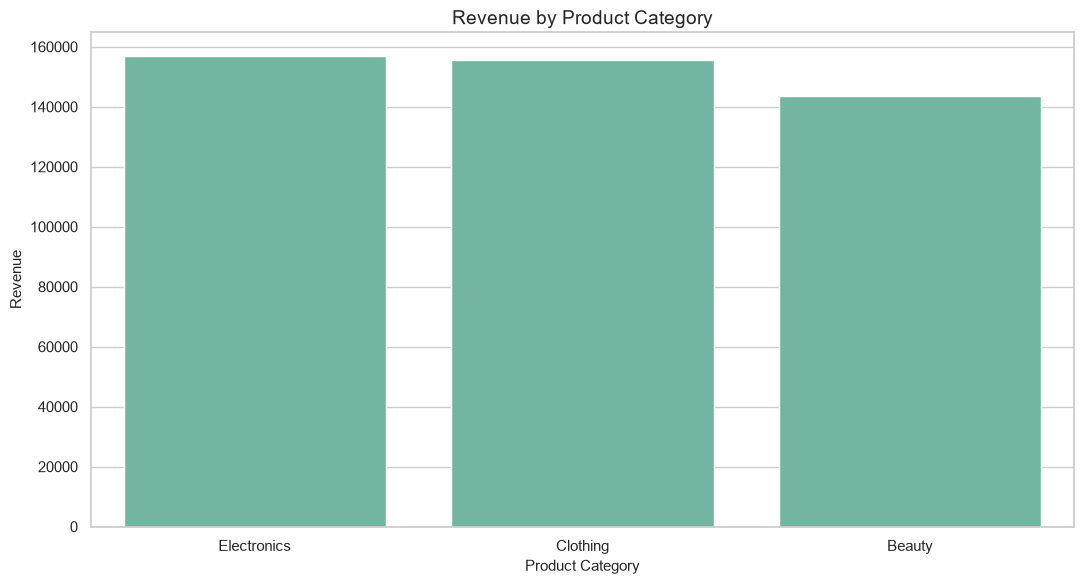

In [12]:
category_revenue = category_summary.sort_values("revenue", ascending=False).reset_index()

ax = sns.barplot(data=category_revenue, x="Product Category", y="revenue")
ax.set_title("Revenue by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

**Observation:** **Electronics** generates the highest category revenue at **$156,905**, but the three categories are close enough that merchandising decisions should focus on margin and customer segment fit, not revenue alone.

## 6. Correlation Heatmap

This heatmap shows relationships among numerical variables.

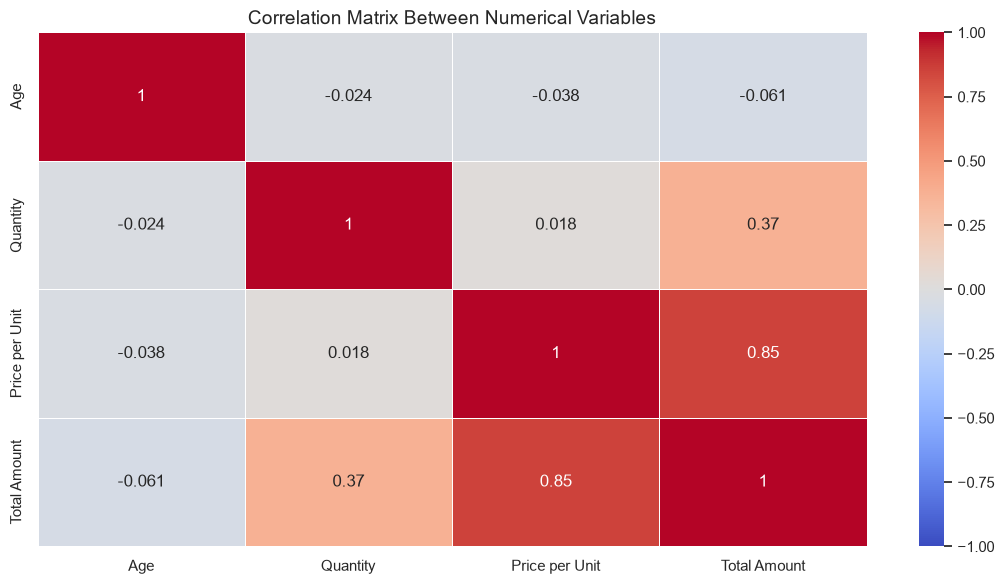

In [13]:
num_for_corr = ["Age", "Quantity", "Price per Unit", "Total Amount"]
corr_matrix = df[num_for_corr].corr()

ax = sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
ax.set_title("Correlation Matrix Between Numerical Variables")
plt.tight_layout()
plt.show()

**Observation:** `Price per Unit` has a strong positive correlation with `Total Amount` (**0.85**), while `Quantity` has a moderate positive relationship (**0.37**). Age has very little correlation with order amount, which means customer age matters more through category preference than through overall spend level.

## 7. Additional Visualization: Category Preference by Age Group

This view looks for a less obvious insight: whether different age groups spend more in different categories.

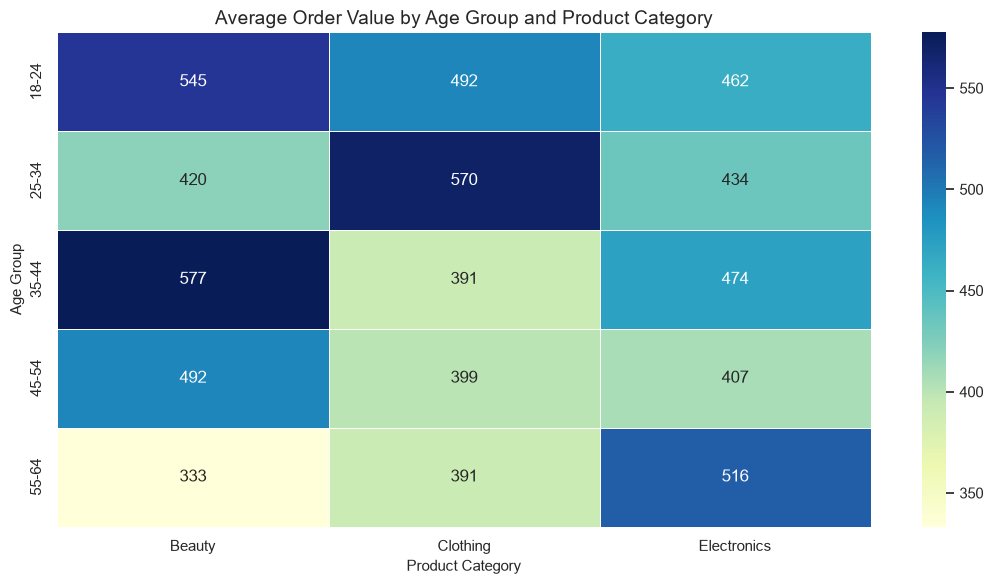

In [14]:
age_category_aov = pd.pivot_table(
    df,
    index="Age Group",
    columns="Product Category",
    values="Total Amount",
    aggfunc="mean",
    observed=False
)

ax = sns.heatmap(age_category_aov, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
ax.set_title("Average Order Value by Age Group and Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Age Group")
plt.tight_layout()
plt.show()

**Observation:** The highest average order value pocket is **35-44 customers buying Beauty**, at about **$577** per transaction. This suggests more useful targeting opportunities than a broad all-customer promotion.

## 8. Conclusion and Actionable Recommendations

1. **Plan inventory and campaigns around peak periods.** Sales peak in May and Q4 is the strongest complete quarter, so the business should prepare stock, staffing, and promotions ahead of these windows.

2. **Target category promotions by age group.** The strongest age-category pockets differ by segment, so campaigns should pair category offers with the age groups that already show higher average order value instead of sending generic discounts to everyone.

3. **Protect and grow high-value categories.** Electronics leads revenue while Clothing leads units sold. Electronics should be managed for revenue and margin, while Clothing can support volume-driven bundles or cross-sell offers.

4. **Avoid over-investing in broad gender segmentation.** Gender revenue and average order value are very similar, so marketing budget is likely better spent on category and age-based targeting.

5. **Improve future data collection.** Add product name/SKU, margin, store/channel, promotion flag, and customer repeat-purchase identifiers. These fields would enable true top-10 product analysis, profitability analysis, and retention/cohort insights.